# Experimento: Comunicação Semântica com Autoencoder

## Hipótese
Em vez de transmitir a imagem bruta (ex: 3.136 bytes no MNIST),  
o transmissor codifica a imagem num **espaço latente compacto** via autoencoder (32 valores),  
transmite apenas esse vetor latente comprimido (≈ 32 bytes em int8),  
e o receptor reconstrói a imagem com **preservação semântica** — queda de acurácia ≤ 5%.

## Pipeline de comunicação semântica
```
TRANSMISSOR                          CANAL               RECEPTOR
Imagem original → [Encoder] → Latente (32B) → [Decoder] → Imagem reconstruída
(3136 bytes MNIST)                    ↑
                          Economia de banda: ~98%
```

## ⚠️ Regra importante
> O dataset das células 4, 4.5, 5, 6 e 7 **devem ser o mesmo**.
> Altere `DATASET` apenas na célula 1 e reexecute tudo do início.

## Fluxo do notebook
| Célula | Etapa |
|--------|-------|
| 1 | Setup — configure DATASET aqui |
| 2 | Subir containers Docker |
| 3 | Baixar datasets dentro do container |
| 4 | Treinar autoencoder via FL (monitoramento em tempo real) |
| **4.5** | **Treinar classificador (necessário para medir preservação semântica)** |
| 5 | Demonstração: canal semântico em 1 imagem |
| 6 | Benchmark em 50 amostras (prova a hipótese) |
| 7 | Gráficos e tabela de escalabilidade |
| 8 | Relatório final da hipótese |

In [ ]:
# Célula 1 — Setup
# Usa apenas bibliotecas padrão + requests. NÃO instala nada.
import json, subprocess, time
from pathlib import Path
import requests

try:
    import pandas as pd; HAS_PANDAS = True
except ImportError:
    HAS_PANDAS = False; print('[aviso] pandas ausente')

try:
    import matplotlib.pyplot as plt
    import matplotlib, numpy as np
    HAS_MATPLOTLIB = True
    print(f'[ok] matplotlib {matplotlib.__version__} disponivel')
except Exception:
    HAS_MATPLOTLIB = False; print('[aviso] matplotlib ausente')

ML_SERVICE  = 'http://localhost:8000'
FL_SERVER   = 'http://localhost:8100'
SHARED_ROOT = Path('shared_data')
RESULTS_DIR = SHARED_ROOT / 'resultados' / 'notebook_monitor'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ════════════════════════════════════════════════════════
#  CONFIGURAÇÃO CENTRAL — altere DATASET aqui para mudar
#  Opcoes: 'mnist' | 'fashion' | 'cifar10' | 'cifar100'
# ════════════════════════════════════════════════════════
DATASET  = 'mnist'
MODEL    = 'cnn_vae'
CLIENTS  = 3
ROUNDS   = 5
EPOCHS   = 5
SEED     = 42
AWGN_CFG = {'enabled': True, 'snr_db': 15}
MASK_CFG = {'enabled': True, 'drop_rate': 0.1, 'fill_value': 0.0}
# ════════════════════════════════════════════════════════

_BYTES_BRUTOS  = {'mnist': 3136, 'fashion': 3136, 'cifar10': 12288, 'cifar100': 12288}
_BYTES_LATENTE = 32

print(f'[ok] Dataset: {DATASET} | Modelo: {MODEL} | {CLIENTS} clientes | {ROUNDS} rounds')
print(f'     Bytes brutos : {_BYTES_BRUTOS[DATASET]} B/imagem')
print(f'     Bytes latente: {_BYTES_LATENTE} B/imagem')
print(f'     Reducao teor.: {(1 - _BYTES_LATENTE/_BYTES_BRUTOS[DATASET])*100:.1f}%')

In [ ]:
# Célula 2 — Subir containers Docker
import json, shutil, subprocess, time
from pathlib import Path
import requests

SHARED_ROOT = Path('shared_data')
for pasta in [SHARED_ROOT / 'fl-weights', SHARED_ROOT / 'resultados']:
    if pasta.exists(): shutil.rmtree(pasta); print(f'[setup] limpo: {pasta}')

for d in [
    SHARED_ROOT / 'ml-data' / 'datasets',
    SHARED_ROOT / 'ml-data' / 'runs',
    SHARED_ROOT / 'ml-data' / 'logs',
    SHARED_ROOT / 'fl-weights',
    SHARED_ROOT / 'resultados' / 'notebook_monitor',
]:
    d.mkdir(parents=True, exist_ok=True)

print('[setup] Subindo containers...')
res = subprocess.run(['docker', 'compose', 'up', '-d', '--build'], capture_output=True, text=True)
if res.returncode != 0:
    print('ERRO:', res.stderr[-2000:])
    raise RuntimeError('docker compose falhou')
print(f'[setup] OK (return code: {res.returncode})')

time.sleep(8)
for nome, porta in [('ml-service', 8000), ('fl-server', 8100)]:
    ok = False
    for _ in range(20):
        try:
            if requests.get(f'http://localhost:{porta}/health', timeout=3).ok:
                ok = True; break
        except Exception: pass
        time.sleep(2)
    print(f'[setup] {nome}: {"OK" if ok else "NAO RESPONDEU"}')
    if not ok: raise RuntimeError(f'Container {nome} nao respondeu')

print('[setup] Todos os containers prontos!')

In [ ]:
# Célula 3 — Baixar todos os datasets DENTRO do container
import time, requests
ML_SERVICE = 'http://localhost:8000'
DATASETS_A_BAIXAR = ['mnist', 'fashion', 'cifar10', 'cifar100']

print(f'[datasets] Solicitando download: {DATASETS_A_BAIXAR}')
r = requests.post(f'{ML_SERVICE}/data/prepare',
    json={'datasets': DATASETS_A_BAIXAR}, timeout=10)
st = r.json()
print(f'[datasets] {st}')

t0, ultimo = time.time(), None
while True:
    try:
        st = requests.get(f'{ML_SERVICE}/data/prepare/status', timeout=5).json()
    except Exception as exc:
        time.sleep(3); continue
    if st.get('current') != ultimo and st.get('current'):
        print(f'[datasets] Baixando {st["current"].upper()}...')
        ultimo = st['current']
    if not st.get('running'):
        print(f'[datasets] Prontos: {st.get("done")}', f'| Erros: {st.get("errors")}' if st.get('errors') else '')
        break
    if time.time() - t0 > 600: print('TIMEOUT'); break
    time.sleep(3)
print('[datasets] Pronto!')

In [ ]:
# Célula 4 — Treinar Autoencoder via FL com monitoramento em tempo real
import json, time
from pathlib import Path
import requests

try:
    DATASET; MODEL; CLIENTS; ROUNDS; EPOCHS; SEED; AWGN_CFG; MASK_CFG
except NameError:
    DATASET='mnist'; MODEL='cnn_vae'; CLIENTS=3; ROUNDS=5; EPOCHS=5; SEED=42
    AWGN_CFG={'enabled':True,'snr_db':15}; MASK_CFG={'enabled':True,'drop_rate':0.1,'fill_value':0.0}

ML_SERVICE = 'http://localhost:8000'; FL_SERVER = 'http://localhost:8100'
LOGS_DIR = Path('shared_data/ml-data/logs'); TIMEOUT = 1800; MAX_FALHAS = 10
KEYWORDS = ('round','ep ','epoch','loss','fedavg','submit','shard','done','error',
            'aggregat','client','loaded','training','batch','lr=')

def _novos(path, offset):
    if not path.exists(): return '', offset
    try: texto = path.read_text(encoding='utf-8', errors='replace')
    except: return '', offset
    return texto[offset:], len(texto)

def _barra(atual, total, w=30):
    pct = min(atual/max(total,1),1.0); c = int(pct*w)
    return chr(9608)*c + chr(9617)*(w-c)

payload = {'dataset':DATASET,'model':MODEL,'clients':CLIENTS,'epochs':EPOCHS,
           'rounds':ROUNDS,'seed':SEED,'compression_mode':'baseline',
           'compression_bits':8,'awgn':AWGN_CFG,'masking':MASK_CFG}
print(f'[treino] {DATASET}/{MODEL} | {CLIENTS} clientes | {ROUNDS}x{EPOCHS}')
st = requests.post(f'{ML_SERVICE}/training/start', json=payload, timeout=15).json()
print(f'[treino] -> {st.get("status")}')
time.sleep(5)

offs = {'server':0}; [offs.update({f'client-{i}':0}) for i in range(1,CLIENTS+1)]
t0=time.time(); falhas=0; ur=-1; ue=''
print('\n' + '='*65 + f'\n  MONITORAMENTO — {DATASET.upper()}\n' + '='*65)

while True:
    elapsed = int(time.time()-t0)
    if elapsed > TIMEOUT: print('TIMEOUT'); break
    try:
        ml = requests.get(f'{ML_SERVICE}/training/status',timeout=5).json(); falhas=0
    except:
        falhas+=1
        if falhas>=MAX_FALHAS: print('Containers nao respondem.'); break
        time.sleep(3); continue
    try:
        s=requests.get(f'{FL_SERVER}/training/status',timeout=5).json()
        estado=s.get('state','?'); rnd=int(s.get('current_round') or 0)
        tot=int(s.get('total_rounds') or ROUNDS); sub=s.get('submitted_clients',[])
        exp=int(s.get('expected_clients') or CLIENTS); hist=s.get('history',[])
    except:
        estado='?'; rnd=0; tot=ROUNDS; sub=[]; exp=CLIENTS; hist=[]
    if rnd!=ur or estado!=ue:
        barra=_barra(rnd,tot); pct=rnd/max(tot,1)*100
        sub_s=', '.join(str(x) for x in sorted(sub)) if sub else 'nenhum'
        print(f'\n  +-- ROUND [{barra}] {rnd}/{tot} ({pct:.0f}%) [{elapsed}s] {estado}')
        print(f'  |   Submetidos: [{sub_s}] / {exp}')
        if hist:
            h=hist[-1]; print(f'  |   Round {h.get("epoch","?"):>2}: loss={h.get("loss",0):.5f}')
        print('  +' + '-'*62)
        ur=rnd; ue=estado
    for i in range(1,CLIENTS+1):
        k=f'client-{i}'; novos,offs[k]=_novos(LOGS_DIR/f'training_{k}.log',offs[k])
        for ln in novos.strip().split('\n'):
            if ln.strip() and any(w in ln.lower() for w in KEYWORDS): print(f'  [client-{i}] {ln.strip()}')
    novos_s,offs['server']=_novos(LOGS_DIR/'training_server.log',offs['server'])
    for ln in novos_s.strip().split('\n'):
        if ln.strip() and any(w in ln.lower() for w in KEYWORDS): print(f'  [server  ] {ln.strip()}')
    if not ml.get('running',False):
        try:
            res=requests.get(f'{ML_SERVICE}/results/latest',timeout=10).json()
            fl=res.get('final_loss','?'); hf=res.get('history',[])
            print(f'\n'+'='*65)
            print(f'  TREINO CONCLUIDO: {elapsed//60}min {elapsed%60}s | loss={fl}')
            if hf:
                print(f'  {"Round":>6} | {"Loss":>10} | {"Bytes Cli":>12} | {"Bytes Srv":>12}')
                print('  '+'-'*48)
                for h in hf:
                    print(f'  {str(h.get("epoch","?")):>6} | {float(h.get("loss",0)):>10.5f} | '
                          f'{int(h.get("bytes_clients",0) or 0):>10,} B | {int(h.get("bytes_global",0) or 0):>10,} B')
            print('='*65)
            Path('shared_data/resultados/notebook_monitor').mkdir(parents=True, exist_ok=True)
            Path('shared_data/resultados/notebook_monitor/treino_ref.json').write_text(
                json.dumps({'dataset':DATASET,'model':MODEL,'final_loss':fl}, indent=2), encoding='utf-8')
            print(f'[treino] Pronto! Agora execute a celula 4.5 para treinar o classificador.')
        except Exception as exc: print(f'Erro: {exc}')
        break
    time.sleep(4)

In [31]:
# Célula 4.5 — Treinar Classificador (necessário para medir preservação semântica)
#
# Por que esta célula existe?
#   O benchmark da célula 6 precisa de um classificador treinado para medir:
#     accuracy_original   → acurácia classificando a imagem ORIGINAL
#     accuracy_reconstruida → acurácia classificando a imagem RECONSTRUIDA
#   A diferença entre os dois é a "queda semântica" — precisa ser ≤ 5%
#
# Este classificador (SimpleClassifier CNN) é treinado em ~2000 amostras,
# demora ~2-4 minutos na CPU e é salvo em /app/data/ml-data/weights/mnist_classifier.pth
#
# ✓ Só precisa ser executado UMA VEZ por dataset.
# ✓ O arquivo fica salvo no volume compartilhado entre execuções.

import time, json, requests
from pathlib import Path

ML_SERVICE = 'http://localhost:8000'

try:
    ref_path = Path('shared_data/resultados/notebook_monitor/treino_ref.json')
    ref = json.loads(ref_path.read_text()) if ref_path.exists() else {}
    DS = ref.get('dataset', DATASET)
except:
    DS = 'mnist'

# Verificar se o classificador já existe
clf_path = Path(f'shared_data/ml-data/weights/{DS}_classifier.pth')
if clf_path.exists():
    print(f'[classificador] Arquivo ja existe: {clf_path}')
    print(f'                Tamanho: {clf_path.stat().st_size / 1024:.1f} KB')
    print('[classificador] Pulando treino. Para re-treinar, delete o arquivo e re-execute.')
else:
    print(f'[classificador] Treinando SimpleClassifier para {DS.upper()}...')
    print(f'                Amostras: 2000 | Epocas: 3 | ~3-5 min na CPU')
    print()

    start = requests.post(f'{ML_SERVICE}/classifier/train-quick', json={
        'dataset': DS, 'epochs': 3, 'samples': 2000, 'seed': 42
    }, timeout=15)
    print(f'[classificador] HTTP {start.status_code} -> {start.json()}')

    t0 = time.time()
    ultimo_ep = 0
    while True:
        try:
            st = requests.get(f'{ML_SERVICE}/classifier/train-quick/status', timeout=5).json()
        except Exception:
            time.sleep(3); continue

        ep = st.get('epoch', 0)
        tot = st.get('total_epochs', 3)
        elapsed = int(time.time() - t0)

        if ep != ultimo_ep and ep > 0:
            pct = ep / max(tot, 1) * 100
            print(f'  [classificador] Epoch {ep}/{tot} ({pct:.0f}%) [{elapsed}s]')
            ultimo_ep = ep

        if not st.get('running'):
            if st.get('error'):
                print(f'\n[classificador] ERRO: {st["error"]}')
            elif st.get('done'):
                acc = st.get('accuracy', 0)
                print()
                print('=' * 55)
                print(f'  CLASSIFICADOR TREINADO em {elapsed}s')
                print(f'  Acuracia de validacao: {acc*100:.1f}%')
                print(f'  Salvo em: {st.get("saved_to")}')
                print('=' * 55)
                if acc < 0.7:
                    print(f'[aviso] Acuracia baixa ({acc*100:.1f}%). Considere aumentar samples/epochs.')
            break

        if elapsed > 600:
            print('[classificador] TIMEOUT'); break
        time.sleep(4)

print()
print('[classificador] Pronto! Execute a celula 5 para a demonstracao do canal semantico.')

[classificador] Treinando SimpleClassifier para MNIST...
                Amostras: 2000 | Epocas: 3 | ~3-5 min na CPU

[classificador] HTTP 200 -> {'status': 'started', 'dataset': 'mnist', 'epochs': 3, 'samples': 2000}
  [classificador] Epoch 3/3 (100%) [4s]

  CLASSIFICADOR TREINADO em 8s
  Acuracia de validacao: 92.4%
  Salvo em: /app/data/ml-data/weights/mnist_classifier.pth

[classificador] Pronto! Execute a celula 5 para a demonstracao do canal semantico.


[semantica] mnist/cnn_vae — executando canal semantico (1 imagem)...

  CANAL SEMANTICO — MNIST
  Label real          : 9
  Pesos carregados    : True
  TRANSMISSAO:
    Sem autoencoder :   3136 bytes
    Com autoencoder :     36 bytes  (vetor latente int8)
    Compressao      : 87.1x | 98.9% economia
  QUALIDADE:
    PSNR : 20.04 dB | SSIM : 0.9246 | MSE: 0.00991
  SEMANTICA:
    Original     -> pred=9 conf=76.4% correto=True
    Reconstruida -> pred=9 conf=76.6% correto=True
    Semantica preservada: SIM


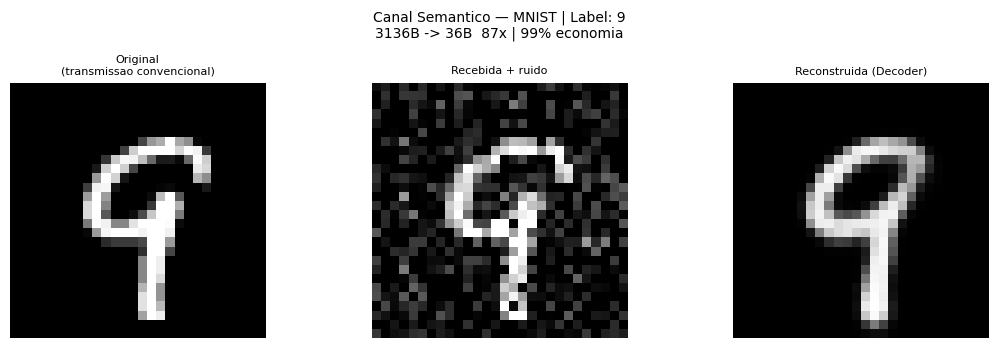

In [32]:
# Célula 5 — Demonstração do Canal Semântico em 1 Imagem
import requests, json
from pathlib import Path
ML_SERVICE = 'http://localhost:8000'

try:
    ref_path = Path('shared_data/resultados/notebook_monitor/treino_ref.json')
    ref = json.loads(ref_path.read_text()) if ref_path.exists() else {}
    DS = ref.get('dataset', DATASET); MD = ref.get('model', MODEL)
except:
    DS = 'mnist'; MD = 'cnn_vae'

try:
    import matplotlib.pyplot as plt, numpy as np; HAS_MPL = True
except: HAS_MPL = False

print(f'[semantica] {DS}/{MD} — executando canal semantico (1 imagem)...')
resp = requests.post(f'{ML_SERVICE}/semantic/process', json={
    'model_type': MD, 'dataset': DS, 'bits': 8,
    'awgn': {'enabled': True, 'snr_db': 15},
    'masking': {'enabled': True, 'drop_rate': 0.1, 'fill_value': 0.0},
    'base_weights': 'latest',
    'classifier': {'enabled': True, 'min_confidence': 0.5, 'top_k': 1},
}, timeout=30)

if resp.status_code != 200:
    print(f'Erro {resp.status_code}: {resp.text[:300]}')
else:
    r = resp.json()
    orig_b=r.get('original_bytes',0); lat_b=r.get('latent_size_int8',0)
    ratio=r.get('compression_ratio',0); bw_red=r.get('bandwidth_reduction_pct',0)
    label=r.get('label','?'); pesos=r.get('weights_loaded',False)

    if not pesos:
        print('  AVISO: pesos nao carregados. Execute a celula 4 primeiro.')

    print('\n' + '='*60)
    print(f'  CANAL SEMANTICO — {DS.upper()}')
    print('='*60)
    print(f'  Label real          : {label}')
    print(f'  Pesos carregados    : {pesos}')
    print(f'  TRANSMISSAO:')
    print(f'    Sem autoencoder : {orig_b:>6} bytes')
    print(f'    Com autoencoder : {lat_b:>6} bytes  (vetor latente int8)')
    print(f'    Compressao      : {ratio:.1f}x | {bw_red:.1f}% economia')
    print(f'  QUALIDADE:')
    print(f'    PSNR : {r.get("psnr",0):.2f} dB | SSIM : {r.get("ssim",0):.4f} | MSE: {r.get("mse",0):.5f}')

    cls=r.get('classifier',{})
    if cls.get('loaded') and cls.get('original') and cls.get('reconstructed'):
        oc=cls['original']; rc=cls['reconstructed']
        ok_sem=oc.get('correct_top1') and rc.get('correct_top1')
        print(f'  SEMANTICA:')
        print(f'    Original     -> pred={oc.get("pred")} conf={oc.get("confidence"):.1%} correto={oc.get("correct_top1")}')
        print(f'    Reconstruida -> pred={rc.get("pred")} conf={rc.get("confidence"):.1%} correto={rc.get("correct_top1")}')
        print(f'    Semantica preservada: {"SIM" if ok_sem else "NAO"}')
    else:
        print('  [aviso] Classificador nao disponivel. Execute a celula 4.5 primeiro.')
    print('='*60)

    if HAS_MPL:
        fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
        titulo_status = '(sem pesos!)' if not pesos else f'{ratio:.0f}x | {bw_red:.0f}% economia'
        fig.suptitle(f'Canal Semantico — {DS.upper()} | Label: {label}\n{orig_b}B -> {lat_b}B  {titulo_status}', fontsize=10)
        titulos = ['Original\n(transmissao convencional)', 'Recebida + ruido', 'Reconstruida (Decoder)']
        imgs = [r.get('original'), r.get('received'), r.get('reconstructed')]
        for ax, img_data, titulo in zip(axes, imgs, titulos):
            if img_data is None:
                ax.text(0.5,0.5,'sem dados',ha='center',va='center',transform=ax.transAxes)
            else:
                arr = np.array(img_data)
                if arr.ndim==3 and arr.shape[0] in (1,3): arr=np.transpose(arr,(1,2,0)).squeeze()
                ax.imshow(np.clip(arr,0,1), cmap='gray' if arr.ndim==2 else None)
            ax.set_title(titulo, fontsize=8); ax.axis('off')
        plt.tight_layout()
        plt.savefig('shared_data/resultados/notebook_monitor/canal_semantico.png', dpi=120)
        plt.show()

In [33]:
# Célula 6 — Benchmark Semântico em 50 Amostras
import json, requests
from pathlib import Path
ML_SERVICE = 'http://localhost:8000'

try:
    ref = json.loads(Path('shared_data/resultados/notebook_monitor/treino_ref.json').read_text())
    DS = ref.get('dataset', DATASET); MD = ref.get('model', MODEL)
except:
    DS = 'mnist'; MD = 'cnn_vae'

print(f'[benchmark] {DS}/{MD} — avaliando 50 imagens...')
resp = requests.post(f'{ML_SERVICE}/experiment/benchmark', json={
    'datasets': [DS], 'models': [MD], 'bits': 8, 'num_samples': 50, 'seed': 42,
    'awgn': {'enabled': True, 'snr_db': 15},
    'masking': {'enabled': True, 'drop_rate': 0.1, 'fill_value': 0.0},
    'classifier': {'enabled': True, 'min_confidence': 0.5, 'top_k': 1},
    'include_samples': False,
}, timeout=300)

if resp.status_code != 200:
    print(f'Erro: {resp.text[:300]}')
else:
    bench = resp.json()
    res = bench.get('results', [{}])[0] if bench.get('results') else {}
    cls = res.get('classification', {})

    orig_b=res.get('original_bytes',0); lat_b=res.get('latent_bytes',0)
    ratio=res.get('compression_ratio_mean',0); bw_red=res.get('bandwidth_reduction_pct',0)

    print('\n' + '='*65)
    print(f'  BENCHMARK — {DS.upper()} / {MD.upper()} — 50 IMAGENS')
    print('='*65)
    print(f'  Pesos treinados : {res.get("weights_loaded")}')
    print(f'  COMPRESSAO:')
    print(f'    {orig_b} B/imagem (bruto) -> {lat_b} B/imagem (latente) | {ratio:.1f}x | {bw_red:.1f}% economia')
    print(f'  QUALIDADE (media +/- desvio):')
    print(f'    MSE  : {res.get("mse_mean",0):.5f} +/- {res.get("mse_std",0):.5f}')
    print(f'    PSNR : {res.get("psnr_mean",0):.2f} +/- {res.get("psnr_std",0):.2f} dB')
    print(f'    SSIM : {res.get("ssim_mean",0):.4f} +/- {res.get("ssim_std",0):.4f}')

    if cls.get('loaded'):
        acc_o=cls.get('accuracy_original',0); acc_r=cls.get('accuracy_reconstructed',0)
        drop=acc_o-acc_r; ok=drop<=0.05
        print(f'  SEMANTICA:')
        print(f'    Acuracia original    : {acc_o*100:.1f}%')
        print(f'    Acuracia reconstruida: {acc_r*100:.1f}%')
        print(f'    Queda semantica      : {drop*100:.2f}%')
        print(f'    Criterio <= 5%       : {"APROVADO" if ok else "REPROVADO"}')
        print('='*65)
        if ok:
            print(f'  HIPOTESE CONFIRMADA: {bw_red:.0f}% menos banda, queda de apenas {drop*100:.2f}%')
        else:
            print('  Hipotese nao confirmada. Aumente ROUNDS/EPOCHS e re-treine.')
        print('='*65)

        b_data = {'dataset':DS,'model':MD,'original_bytes':orig_b,'latent_bytes':lat_b,
                  'compression_ratio':ratio,'bandwidth_reduction_pct':bw_red,
                  'psnr_mean':res.get('psnr_mean',0),'ssim_mean':res.get('ssim_mean',0),
                  'mse_mean':res.get('mse_mean',0),
                  'accuracy_original':acc_o,'accuracy_reconstructed':acc_r,
                  'semantic_drop':drop,'criterio_5pct_ok':ok,
                  'scalability':res.get('scalability',{})}
        Path('shared_data/resultados/notebook_monitor/benchmark.json').write_text(
            json.dumps(b_data, indent=2), encoding='utf-8')
        print('[benchmark] Salvo em shared_data/resultados/notebook_monitor/benchmark.json')
    else:
        print('[aviso] Classificador nao disponivel. Execute a celula 4.5 primeiro!')

[benchmark] mnist/cnn_vae — avaliando 50 imagens...

  BENCHMARK — MNIST / CNN_VAE — 50 IMAGENS
  Pesos treinados : True
  COMPRESSAO:
    3136 B/imagem (bruto) -> 36 B/imagem (latente) | 87.1x | 98.9% economia
  QUALIDADE (media +/- desvio):
    MSE  : 0.00975 +/- 0.00437
    PSNR : 20.61 +/- 2.22 dB
    SSIM : 0.9111 +/- 0.0436
  SEMANTICA:
    Acuracia original    : 90.0%
    Acuracia reconstruida: 86.0%
    Queda semantica      : 4.00%
    Criterio <= 5%       : APROVADO
  HIPOTESE CONFIRMADA: 99% menos banda, queda de apenas 4.00%
[benchmark] Salvo em shared_data/resultados/notebook_monitor/benchmark.json


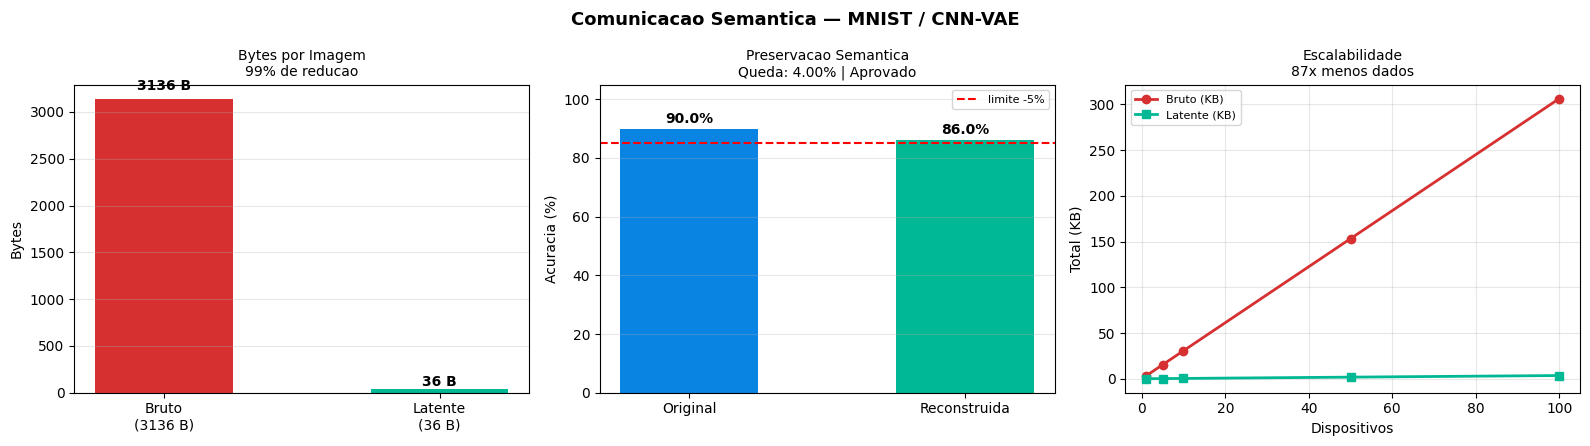

      Disp |   Bruto (KB) | Latente (KB) |  Economia (KB)
  ----------------------------------------------------
         1 |          3.1 |          0.0 |            3.0
         5 |         15.3 |          0.2 |           15.1
        10 |         30.6 |          0.3 |           30.3
        50 |        153.1 |          1.8 |          151.4
       100 |        306.2 |          3.5 |          302.7


In [34]:
# Célula 7 — Gráficos e Tabela de Escalabilidade
import json
from pathlib import Path
try: import matplotlib.pyplot as plt, numpy as np; HAS_MPL = True
except: HAS_MPL = False

bp = Path('shared_data/resultados/notebook_monitor/benchmark.json')
if not bp.exists():
    print('Execute a celula 6 primeiro.')
else:
    b = json.loads(bp.read_text(encoding='utf-8'))
    DS=b.get('dataset','mnit'); orig_b=b.get('original_bytes',0); lat_b=b.get('latent_bytes',0)
    ratio=b.get('compression_ratio',0); bw_red=b.get('bandwidth_reduction_pct',0)
    acc_o=b.get('accuracy_original',0); acc_r=b.get('accuracy_reconstructed',0)
    drop=b.get('semantic_drop',0); ok=b.get('criterio_5pct_ok',False)
    scalab=b.get('scalability',{})

    if HAS_MPL:
        fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
        fig.suptitle(f'Comunicacao Semantica — {DS.upper()} / CNN-VAE', fontsize=13, fontweight='bold')

        ax=axes[0]
        bars=ax.bar([f'Bruto\n({orig_b} B)',f'Latente\n({lat_b} B)'],[orig_b,lat_b],
                    color=['#d63031','#00b894'],width=0.5)
        ax.set_title(f'Bytes por Imagem\n{bw_red:.0f}% de reducao',fontsize=10)
        ax.set_ylabel('Bytes'); ax.grid(axis='y',alpha=0.3)
        for bar,val in zip(bars,[orig_b,lat_b]):
            ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()*1.02,
                    f'{val} B',ha='center',va='bottom',fontsize=10,fontweight='bold')

        ax=axes[1]
        cor='#00b894' if ok else '#e17055'
        bars2=ax.bar(['Original','Reconstruida'],[acc_o*100,acc_r*100],color=['#0984e3',cor],width=0.5)
        ax.set_ylim(0,105)
        ax.axhline(y=(acc_o-0.05)*100,color='red',linestyle='--',linewidth=1.5,label='limite -5%')
        ax.set_title(f'Preservacao Semantica\nQueda: {drop*100:.2f}% | {"Aprovado" if ok else "Reprovado"}',fontsize=10)
        ax.set_ylabel('Acuracia (%)'); ax.legend(fontsize=8); ax.grid(axis='y',alpha=0.3)
        for bar,val in zip(bars2,[acc_o*100,acc_r*100]):
            ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+1,
                    f'{val:.1f}%',ha='center',va='bottom',fontsize=10,fontweight='bold')

        ax=axes[2]
        if scalab:
            ns,ko,kl=[],[],[]
            for key,vals in scalab.items():
                ns.append(int(key.replace('_devices','')))
                ko.append(vals.get('total_original_kb',0)); kl.append(vals.get('total_latent_kb',0))
            ax.plot(ns,ko,'o-',color='#d63031',label='Bruto (KB)',linewidth=2)
            ax.plot(ns,kl,'s-',color='#00b894',label='Latente (KB)',linewidth=2)
            ax.set_title(f'Escalabilidade\n{ratio:.0f}x menos dados',fontsize=10)
            ax.set_xlabel('Dispositivos'); ax.set_ylabel('Total (KB)')
            ax.legend(fontsize=8); ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig('shared_data/resultados/notebook_monitor/graficos_semantica.png',dpi=130,bbox_inches='tight')
        plt.show()

    if scalab:
        print(f'  {"Disp":>8} | {"Bruto (KB)":>12} | {"Latente (KB)":>12} | {"Economia (KB)":>14}')
        print('  '+'-'*52)
        for key,vals in scalab.items():
            n=key.replace('_devices',''); ob=vals.get('total_original_kb',0); lb=vals.get('total_latent_kb',0)
            print(f'  {n:>8} | {ob:>12.1f} | {lb:>12.1f} | {ob-lb:>14.1f}')

In [35]:
# Célula 8 — Relatório Final da Hipótese
import json, subprocess
from pathlib import Path

bp = Path('shared_data/resultados/notebook_monitor/benchmark.json')
tp = Path('shared_data/resultados/notebook_monitor/treino_ref.json')

if not bp.exists():
    print('Execute as celulas 4, 4.5 e 6 primeiro.')
else:
    b=json.loads(bp.read_text(encoding='utf-8'))
    t=json.loads(tp.read_text(encoding='utf-8')) if tp.exists() else {}

    DS=b.get('dataset',t.get('dataset','N/A')); orig_b=b.get('original_bytes',0); lat_b=b.get('latent_bytes',0)
    ratio=b.get('compression_ratio',0); bw_red=b.get('bandwidth_reduction_pct',0)
    acc_o=b.get('accuracy_original',0); acc_r=b.get('accuracy_reconstructed',0)
    drop=b.get('semantic_drop',0); ok=b.get('criterio_5pct_ok',False)
    psnr=b.get('psnr_mean',0); ssim=b.get('ssim_mean',0); c1=bw_red>0; c2=ok

    print('='*65)
    print('  RELATORIO FINAL — COMUNICACAO SEMANTICA COM AUTOENCODER')
    print('='*65)
    print(f'  Dataset : {DS.upper()} | Modelo: {t.get("model","N/A").upper()}')
    print(f'  Loss FL : {t.get("final_loss","N/A")}')
    print()
    print(f'  [C1] Reducao de banda    : {"APROVADO" if c1 else "REPROVADO"} ({bw_red:.1f}% economia)')
    print(f'  [C2] Queda semantica<=5% : {"APROVADO" if c2 else "REPROVADO"} (queda={drop*100:.2f}%)')
    print(f'  [C3] Reprodutibilidade   : OK (seed=42)')
    print()
    if c1 and c2:
        print(f'  HIPOTESE CONFIRMADA')
        print(f'  O CNN-VAE ({DS}) comprime imagens {ratio:.0f}x ({bw_red:.0f}% menos banda)')
        print(f'  com queda semantica de apenas {drop*100:.2f}% (limite: 5%).')
    else:
        print('  HIPOTESE NAO CONFIRMADA INTEGRALMENTE')
        if not c2: print('  -> Aumente ROUNDS/EPOCHS na celula 1 e re-execute 4,4.5,6.')
    print('='*65)

    linhas = [
        ('Dataset', DS.upper()),
        ('Bytes originais', f'{orig_b} B'),
        ('Bytes latente int8', f'{lat_b} B'),
        ('Razao de compressao', f'{ratio:.1f}x'),
        ('Reducao de banda', f'{bw_red:.1f}%'),
        ('PSNR', f'{psnr:.2f} dB'),
        ('SSIM', f'{ssim:.4f}'),
        ('Acuracia original', f'{acc_o*100:.1f}%'),
        ('Acuracia reconstruida', f'{acc_r*100:.1f}%'),
        ('Queda semantica', f'{drop*100:.2f}%'),
        ('Criterio <= 5%', 'Aprovado' if c2 else 'Reprovado'),
    ]
    print()
    try:
        import pandas as pd
        df=pd.DataFrame(linhas,columns=['Metrica','Valor']); df.index=['']*len(df); display(df)
    except:
        for m,v in linhas: print(f'  {m:<30}: {v}')

    print('\n  LOGS FINAIS:')
    for nome in ['fl-client-1','fl-client-2','fl-client-3']:
        res=subprocess.run(['docker','compose','logs','--tail','3',nome],capture_output=True,text=True)
        saida=(res.stdout or res.stderr or '').strip()[-200:]
        print(f'  --- {nome} ---\n  {saida if saida else "(sem logs)"}')

  RELATORIO FINAL — COMUNICACAO SEMANTICA COM AUTOENCODER
  Dataset : MNIST | Modelo: CNN_VAE
  Loss FL : 0.010379

  [C1] Reducao de banda    : APROVADO (98.9% economia)
  [C2] Queda semantica<=5% : APROVADO (queda=4.00%)
  [C3] Reprodutibilidade   : OK (seed=42)

  HIPOTESE CONFIRMADA
  O CNN-VAE (mnist) comprime imagens 87x (99% menos banda)
  com queda semantica de apenas 4.00% (limite: 5%).



,Metrica,Valor
,Dataset,MNIST
,Bytes originais,3136 B
,Bytes latente int8,36 B
,Razao de compressao,87.1x
,Reducao de banda,98.9%
,PSNR,20.61 dB
,SSIM,0.9111
,Acuracia original,90.0%
,Acuracia reconstruida,86.0%
,Queda semantica,4.00%



  LOGS FINAIS:
  --- fl-client-1 ---
  _client_1  | INFO:     172.21.0.2:54286 - "GET /logs?since=44 HTTP/1.1" 200 OK
fl_client_1  | [02:58:40] [client-1] Server state=done; exiting
fl_client_1  | [02:58:40] [client-1] Training loop exited
  --- fl-client-2 ---
  _client_2  | [02:58:39] [client-2] Server state=done; exiting
fl_client_2  | [02:58:39] [client-2] Training loop exited
fl_client_2  | INFO:     172.21.0.2:43750 - "GET /logs?since=47 HTTP/1.1" 200 OK
  --- fl-client-3 ---
  _client_3  | INFO:     172.21.0.2:44386 - "GET /logs?since=47 HTTP/1.1" 200 OK
fl_client_3  | [02:58:40] [client-3] Server state=done; exiting
fl_client_3  | [02:58:40] [client-3] Training loop exited
